### Neural Network Classification with PyTorch
- Classification is a problem of predicting whether something is one thing or another

1. Make classification data and get it ready

In [2]:
import sklearn
from sklearn.datasets import make_circles

n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [3]:
print(f"First 5 samples of X:\n {X[:5]}")
print(f"First 5 samples of y:\n {y[:5]}")
print("We have 2 features of X for 1 feautre of y")

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y:
 [1 1 1 1 0]
We have 2 features of X for 1 feautre of y


In [4]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({'X1': X[:, 0],
                        'X2': X[:, 1],
                        'label': y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


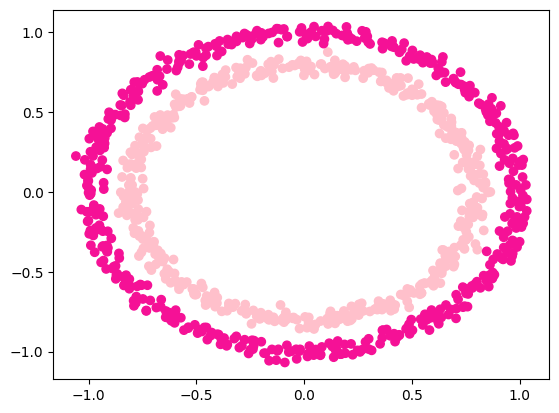

In [5]:
# Visualise
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
colors = ["#f51196", "#FF69B4", "#FFC0CB"] 
cmap = mcolors.LinearSegmentedColormap.from_list("custom_pink", colors)

plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=cmap)
plt.show()

### 1.1 Check input and output shapes

In [6]:
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X : {X_sample} and the same for y : {y_sample}")
print(f"Shapes for one sample of X : {X_sample.shape} and the same for y : {y_sample.shape}")

Values for one sample of X : [0.75424625 0.23148074] and the same for y : 1
Shapes for one sample of X : (2,) and the same for y : ()


### 1.2 Turn data into tensors and create train and test splits

In [8]:
# Turn data into tensors
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [9]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.2, 
                                                    train_size=0.8, 
                                                    random_state=42)

### 2. Building a model

Let's build a model to classify our dots 

To do so, we want to:
1. Set up device agnostic code
2. Construct a model (by subclassing nn.Module)
3. Define a loss function and optimiser
4. Creating a training and test loop

In [10]:
import torch
from torch import nn

# Device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Let's create a model that:
1. Subclass nn.Module
2. Create 2 nn.Linear() layers capable of handling the shapes of our data
3. Define a forward() method 
4. Instantiate an instance of our model class and send to target device

In [11]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()

        # Create 2 nn.Linear() layers
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features and upscales to 5
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features and downscales to 1 (same shape as y)

    def forward(self, x):
        return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> output
    
# Instantiate an instance of our model class and send it to the target device 
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [12]:
# Let's replicate the model above using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1492,  0.1407],
                      [ 0.1620, -0.5984],
                      [ 0.1925, -0.3035],
                      [ 0.3077, -0.1991],
                      [-0.4255, -0.1740]])),
             ('0.bias', tensor([ 0.5189,  0.2409, -0.0367, -0.1791, -0.4722])),
             ('1.weight',
              tensor([[-0.3723,  0.0854, -0.1676, -0.1475,  0.2212]])),
             ('1.bias', tensor([0.1166]))])

In [13]:
# Make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions : {len(untrained_preds)}, Shape : {untrained_preds.shape}")
print(f"Length of test samples : {len(X_test)}, Shape : {X_test.shape}")
print(f"\nFirst 10 predictions :\n{untrained_preds[:10]}")
print(f"\nFirst 10 labels :\n{y_test[:10]}")

Length of predictions : 200, Shape : torch.Size([200, 1])
Length of test samples : 200, Shape : torch.Size([200, 2])

First 10 predictions :
tensor([[-0.0899],
        [-0.1904],
        [ 0.0416],
        [-0.1266],
        [-0.1679],
        [-0.2277],
        [-0.3446],
        [-0.3538],
        [ 0.0502],
        [-0.1995]])

First 10 labels :
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Set up loss function or optimiser

Which loss function or optimiser should you use?
- For regression MAE or MSE
- For classification binary cross entropy or categorical cross entropy

In [14]:
# Set up the loss function
loss_fn = nn.BCEWithLogitsLoss() # sigmoid activation function built-in

optimiser = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)


In [15]:
# Calculate accuracy 
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

### 3. Train model

To train our model, we are going to need to use a training loop:
1. Forward pass
2. Calculate the loss
3. Optimiser zero grad
4. Loss backward (backpropagation)
5. Optimiser step (gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw logits 

We can convert these logits into prediction probabilities by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification)

In [16]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0899],
        [-0.1904],
        [ 0.0416],
        [-0.1266],
        [-0.1679]])

In [17]:
# Use the sigmoid activation function on our model logits to turn them into some prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4775],
        [0.4525],
        [0.5104],
        [0.4684],
        [0.4581]])

For our prediction probability values, we need to perform a range-stype rounding on them:
- 'y_pred_probs' >= 0.5, 'y=1' (class 1)
- 'y_pred_probs' < 0.5, 'y=0' (class 0)

In [18]:
# Find the predicted labels 
y_preds = torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Checking the equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 0.])

### 3.2 Building a training and testing loop

In [32]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device 
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training (can be functionised)
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

    # 2. Loss / accuracy
    loss = loss_fn(y_logits, # nn.BCEWithLogitsLoss expects raw logits as input
                   y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)
    
    # 3. Optimiser zero grad
    optimiser.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    #5. Optimiser step (gradient descent)
    optimiser.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
         # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

         # 2. Loss / accuracy
        test_loss = loss_fn(test_logits, # nn.BCEWithLogitsLoss expects raw logits as input
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                                y_pred=test_pred)
        
        # Print out what's happening 
        if epoch % 10 == 0:
            print(f"Epoch : {epoch} | Loss : {loss:.5f} | Acc : {acc:.2f}% | Test loss : {test_loss:.5f} | Test acc : {test_acc:.2f}%")
 

Epoch : 0 | Loss : 0.69669 | Acc : 47.75% | Test loss : 0.69289 | Test acc : 50.50%
Epoch : 10 | Loss : 0.69658 | Acc : 47.88% | Test loss : 0.69281 | Test acc : 51.00%
Epoch : 20 | Loss : 0.69647 | Acc : 48.25% | Test loss : 0.69273 | Test acc : 51.50%
Epoch : 30 | Loss : 0.69638 | Acc : 48.25% | Test loss : 0.69267 | Test acc : 50.50%
Epoch : 40 | Loss : 0.69629 | Acc : 47.88% | Test loss : 0.69260 | Test acc : 50.50%
Epoch : 50 | Loss : 0.69620 | Acc : 47.75% | Test loss : 0.69255 | Test acc : 51.50%
Epoch : 60 | Loss : 0.69612 | Acc : 48.00% | Test loss : 0.69249 | Test acc : 52.00%
Epoch : 70 | Loss : 0.69605 | Acc : 48.00% | Test loss : 0.69245 | Test acc : 52.50%
Epoch : 80 | Loss : 0.69598 | Acc : 48.25% | Test loss : 0.69241 | Test acc : 52.50%
Epoch : 90 | Loss : 0.69591 | Acc : 48.25% | Test loss : 0.69237 | Test acc : 52.00%


### 4. Make predictions and evaluate the model


In [24]:
import torch
import torchvision
# Your remaining imports...
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
    print("helper_function.py already exists, skipping download")
else:
    print("Download helper_function.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

from helper_functions import plot_decision_boundary, plot_predictions

helper_function.py already exists, skipping download


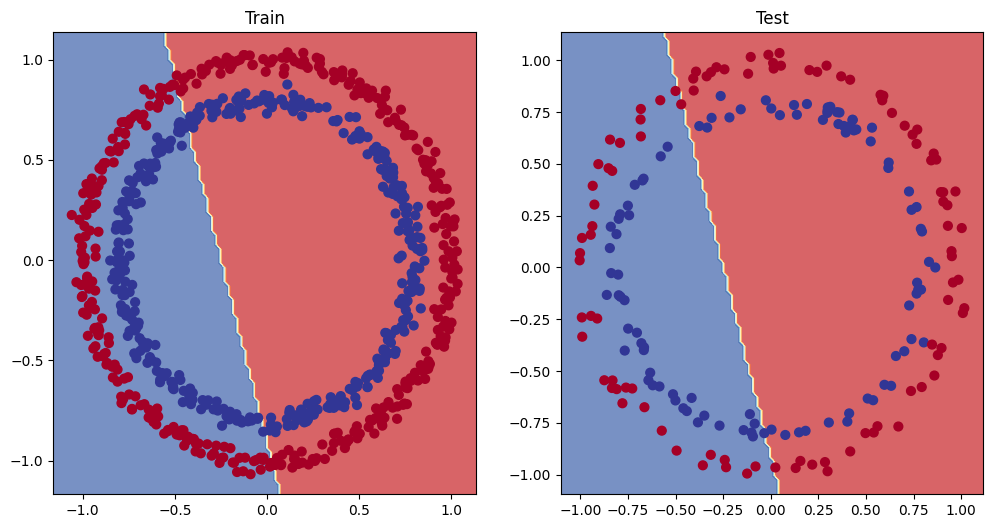

In [35]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)


### 5. Improving a model (from a model perspective)
- Add more layers - give the model more chances to learn about patterns in the data
- Add more hidden units - go from 5 to 10
- Fit for longer
- Changing the activation functions 
- Change the learning rate
- Change the loss function

There are all from a model's perspective as they deal directly with the model, rather than the data

And because these options are all values we can change, they are referred to as **hyperparameters**

Let's try and improve our model by:
- Adding more hidden units : 5 -> 10
- Increase the number of layers : 2 -> 3
- Increase the number of epochs : 100 -> 1000

In [39]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))
    
model_1 = CircleModelV1().to(device)


In [40]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimiser
optimiser = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [41]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 1000

# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_1.train()
    # 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2. Calc loss / acc
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)
    
    # 3. Optimiser zero grad
    optimiser.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimiser step
    optimiser.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)
        
    if epoch % 100 == 0:
        print(f"Epoch : {epoch} | Loss : {loss:.5f} | Acc : {acc:.2f}% | Test loss : {test_loss:.5f} | Test acc : {test_acc:.2f}%")

Epoch : 0 | Loss : 0.69396 | Acc : 50.88% | Test loss : 0.69261 | Test acc : 51.00%
Epoch : 100 | Loss : 0.69369 | Acc : 50.25% | Test loss : 0.69269 | Test acc : 50.00%
Epoch : 200 | Loss : 0.69351 | Acc : 50.12% | Test loss : 0.69282 | Test acc : 49.50%
Epoch : 300 | Loss : 0.69339 | Acc : 50.50% | Test loss : 0.69295 | Test acc : 49.00%
Epoch : 400 | Loss : 0.69329 | Acc : 50.38% | Test loss : 0.69309 | Test acc : 48.50%
Epoch : 500 | Loss : 0.69322 | Acc : 49.88% | Test loss : 0.69322 | Test acc : 49.50%
Epoch : 600 | Loss : 0.69317 | Acc : 49.50% | Test loss : 0.69335 | Test acc : 53.00%
Epoch : 700 | Loss : 0.69313 | Acc : 49.38% | Test loss : 0.69347 | Test acc : 50.50%
Epoch : 800 | Loss : 0.69309 | Acc : 50.00% | Test loss : 0.69358 | Test acc : 51.00%
Epoch : 900 | Loss : 0.69307 | Acc : 50.62% | Test loss : 0.69368 | Test acc : 47.50%


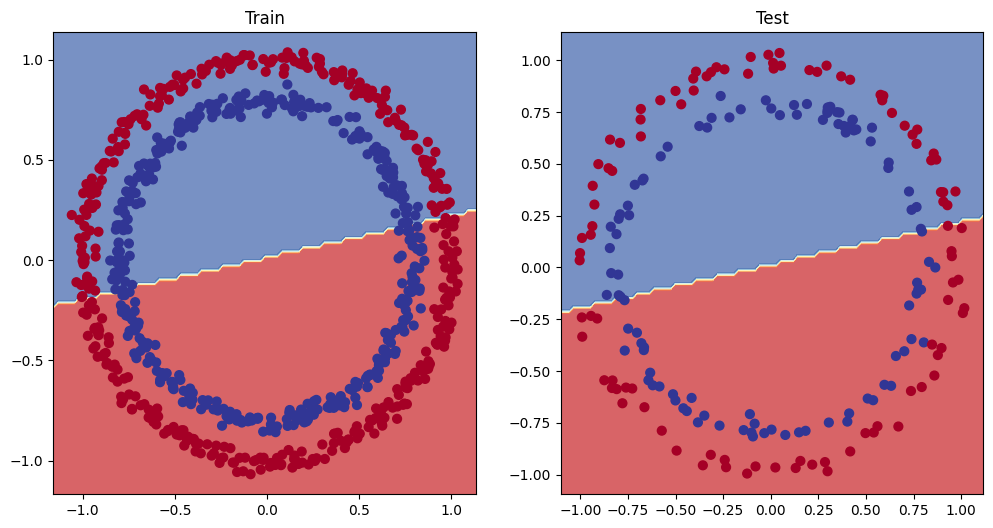

In [43]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Preparing data to see if our model can fit a straight line

In [44]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

In [50]:
# Create train and trst splits
X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(X_regression, y_regression, train_size=0.8, test_size=0.2)
len(y_train_regression)

80

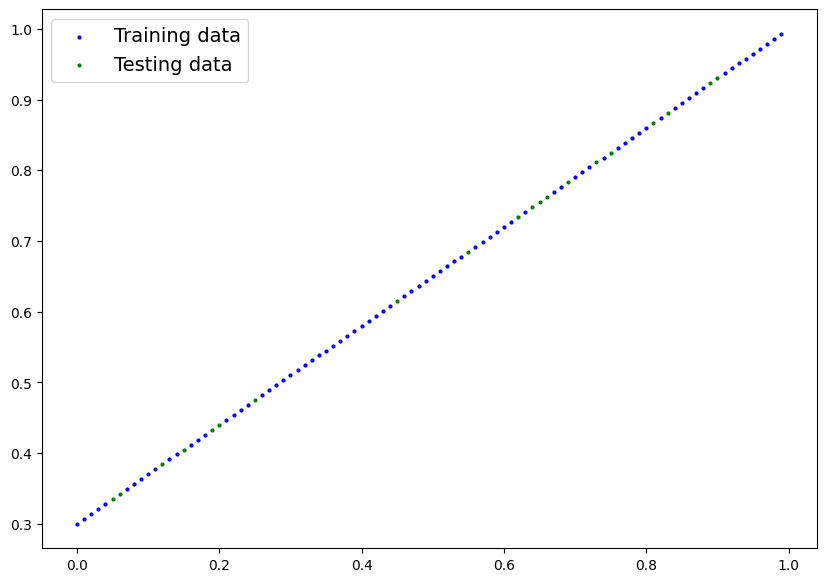

In [51]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression)

### 5.2 Adjusting model 1 to fit a straight line

In [56]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1),
).to(device)

In [62]:
# Create a loss function
loss_fn = nn.L1Loss()

# Create an optimiser
optimiser = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.01)

In [63]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 1000

# Put data on the target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ### Training
    y_pred = model_2(X_train_regression)
    loss = loss_fn(y_pred, y_train_regression)
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
        test_pred = model_2(X_test_regression)
        test_loss = loss_fn(test_pred,
                            y_test_regression)
        
    if epoch % 100 == 0:
        print(f"Epoch : {epoch} | Loss : {loss:.5f} | Test loss : {test_loss:.5f}")

Epoch : 0 | Loss : 0.05496 | Test loss : 0.04276
Epoch : 100 | Loss : 0.00190 | Test loss : 0.00891
Epoch : 200 | Loss : 0.00103 | Test loss : 0.00977
Epoch : 300 | Loss : 0.00285 | Test loss : 0.00791
Epoch : 400 | Loss : 0.00198 | Test loss : 0.00868
Epoch : 500 | Loss : 0.00111 | Test loss : 0.00953
Epoch : 600 | Loss : 0.00025 | Test loss : 0.01037
Epoch : 700 | Loss : 0.00324 | Test loss : 0.00734
Epoch : 800 | Loss : 0.00408 | Test loss : 0.00630
Epoch : 900 | Loss : 0.00491 | Test loss : 0.00538


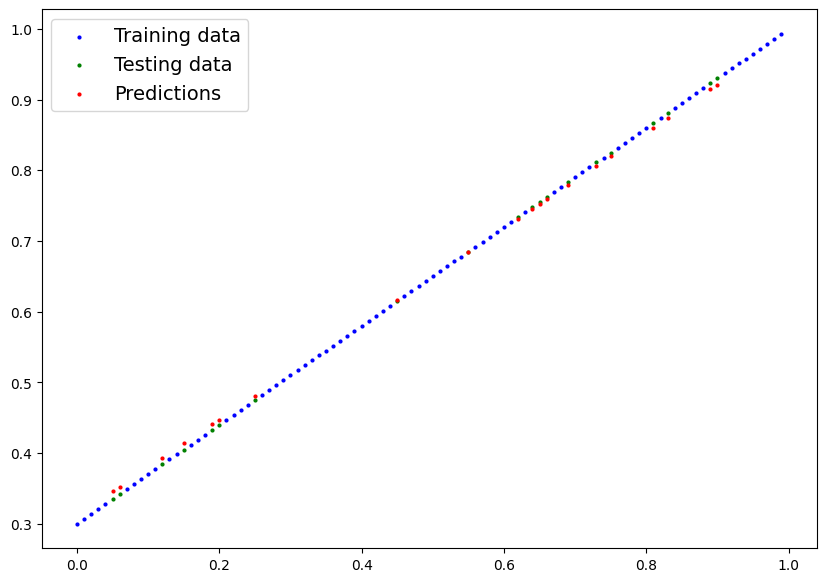

In [65]:
model_2.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression,
                 predictions=y_preds)

### The missing piece : non-linearity

### 6.1 Recreating non-linear data (circles)

In [69]:
import sklearn
from sklearn.datasets import make_circles

n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

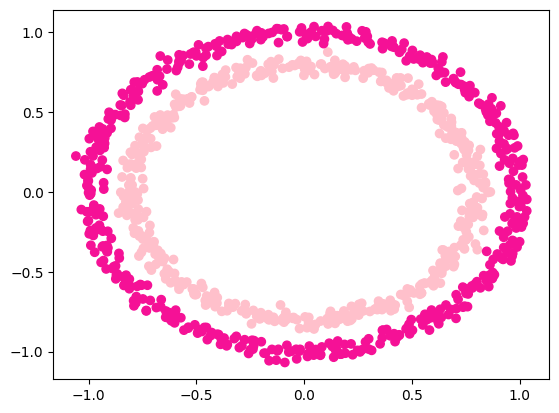

In [71]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
colours = ["#f51196", "#FF69B4", "#FFC0CB"] 
cmap = mcolors.LinearSegmentedColormap.from_list("custom_pink", colours)

plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=cmap)
plt.show()

In [73]:
import torch
from torch import nn

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [74]:
 # Split data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.2, 
                                                    train_size=0.8, 
                                                    random_state=42)

### 6.2 Building a model with non-linearity

Artificial nn's are a large combination of linear and non-linear functions which are potentially able to find trends in data

In [87]:
# Build a model with non-linear activation functions
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10) 
        self.layer_2 = nn.Linear(in_features=10, out_features=20)
        self.layer_3 = nn.Linear(in_features=20, out_features=20) 
        self.layer_4 = nn.Linear(in_features=20, out_features=10)
        self.layer_5 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_5(self.relu(self.layer_4(self.relu(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))))))
    
model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=20, bias=True)
  (layer_3): Linear(in_features=20, out_features=20, bias=True)
  (layer_4): Linear(in_features=20, out_features=10, bias=True)
  (layer_5): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [97]:
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimiser
optimiser = torch.optim.SGD(params=model_3.parameters(),
                            lr=0.01)

### 6.3 Training a model with non-linearity

In [98]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 10000

# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_3.train()
    # 1. Forward pass
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2. Calc loss / acc
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)
    
    # 3. Optimiser zero grad
    optimiser.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimiser step
    optimiser.step()

    ### Testing
    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)
        
    if epoch % 5000 == 0:
        print(f"Epoch : {epoch} | Loss : {loss:.5f} | Acc : {acc:.2f}% | Test loss : {test_loss:.5f} | Test acc : {test_acc:.2f}%")

Epoch : 0 | Loss : 0.68799 | Acc : 55.88% | Test loss : 0.68753 | Test acc : 53.00%
Epoch : 5000 | Loss : 0.58821 | Acc : 81.75% | Test loss : 0.58388 | Test acc : 83.50%


### 6.4 Evaluating a model trained with non-linear activation functions

In [101]:
# Makes predictions 
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

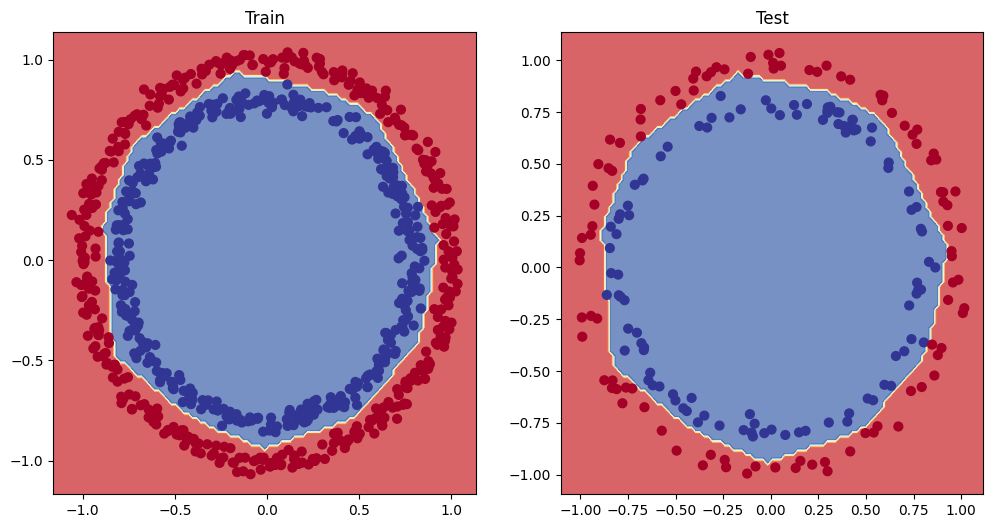

In [102]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

### 7. Replicating non-linear activation functions 

In [105]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

In [110]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.max(torch.tensor(0), x) # inputs must be tensors 

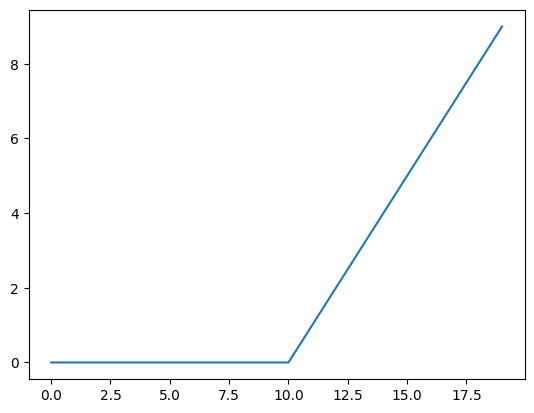

In [115]:
plt.plot(relu(A))
plt.show()

In [116]:
def sigmoid(x: torch.Tensor) -> torch.Tensor:
    return 1 / (1 + torch.exp(-x))

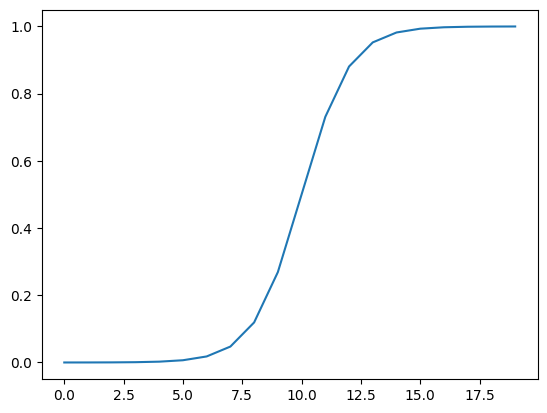

In [119]:
plt.plot(sigmoid(A))
plt.show()

### 8. Putting it all together with a multi-class classification problem

### 8.1 Creating a toy multi-class dataset

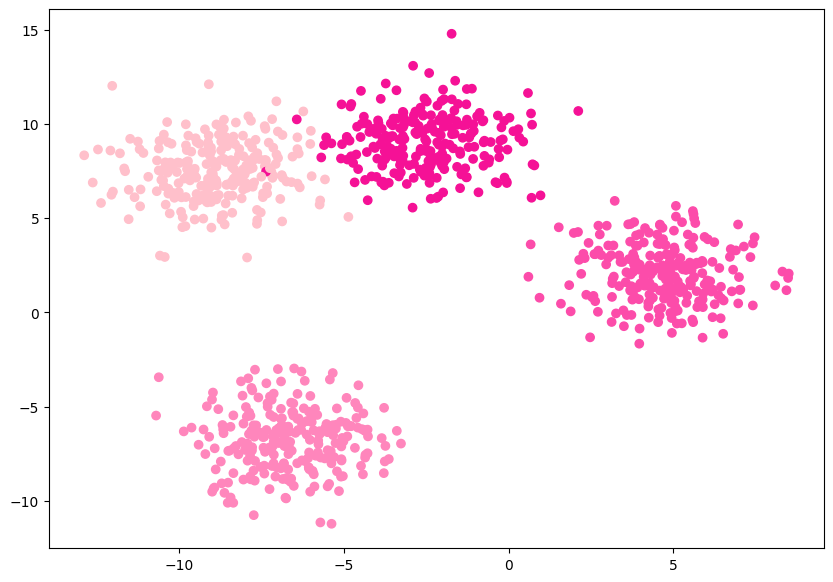

In [133]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

# 2. Turn data into tensors 
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

# 3. Train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)

# 4. Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=cmap)
plt.show()

### 8.2 Building a multi-class classification model in PyTorch

In [136]:
# Build a multi-class classification model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        ) 

    def forward(self, x):
        return self.linear_layer_stack(x)
    
model_4 = BlobModel(2, 4).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [137]:
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimiser
optimiser = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.01)

In [138]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 100

# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_4.train()
    # 1. Forward pass
    y_logits = model_4(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2. Calc loss / acc
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)
    
    # 3. Optimiser zero grad
    optimiser.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimiser step
    optimiser.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)
        
    if epoch % 5000 == 0:
        print(f"Epoch : {epoch} | Loss : {loss:.5f} | Acc : {acc:.2f}% | Test loss : {test_loss:.5f} | Test acc : {test_acc:.2f}%")

ValueError: Target size (torch.Size([800])) must be the same as input size (torch.Size([800, 4]))